# <center><strong>Bank Customer Churn Analysis</strong></center>
--------------------------------


#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

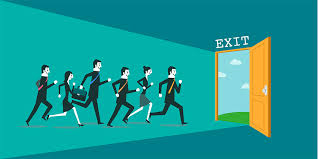

In [1]:
from IPython.display import Image
Image(filename='Bank.jpeg')

--------------------------------
--------------------------------
--------------------------------

## **Import Libraries**


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.show()

def kde(data, col):
    plt.figure(figsize=(14,	4))
    sns.kdeplot(data[col], fill=True,	color='red', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

---------------------------------------
---------------------------------------
---------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [4]:
df = pd.read_csv("bank customer churn dataset.csv")

In [5]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

0

------------------------
------------------------
### **Data Cleaning**
------------------------

In [11]:
df.rename(columns={'HasCrCard': 'Has credit card','IsActiveMember':'Is Active Member','CreditScore':'Credit Score',
                   'NumOfProducts':'Number Of Products','EstimatedSalary':'Estimated Salary','Exited':'Churned'} ,inplace=True)

In [12]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

-----------------------------------------
-----------------------------------------

### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Credit Score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
Number Of Products,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
Has credit card,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
Is Active Member,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
Estimated Salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Churned,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


-----------------------------------

#### **Checking Correlation between the features**

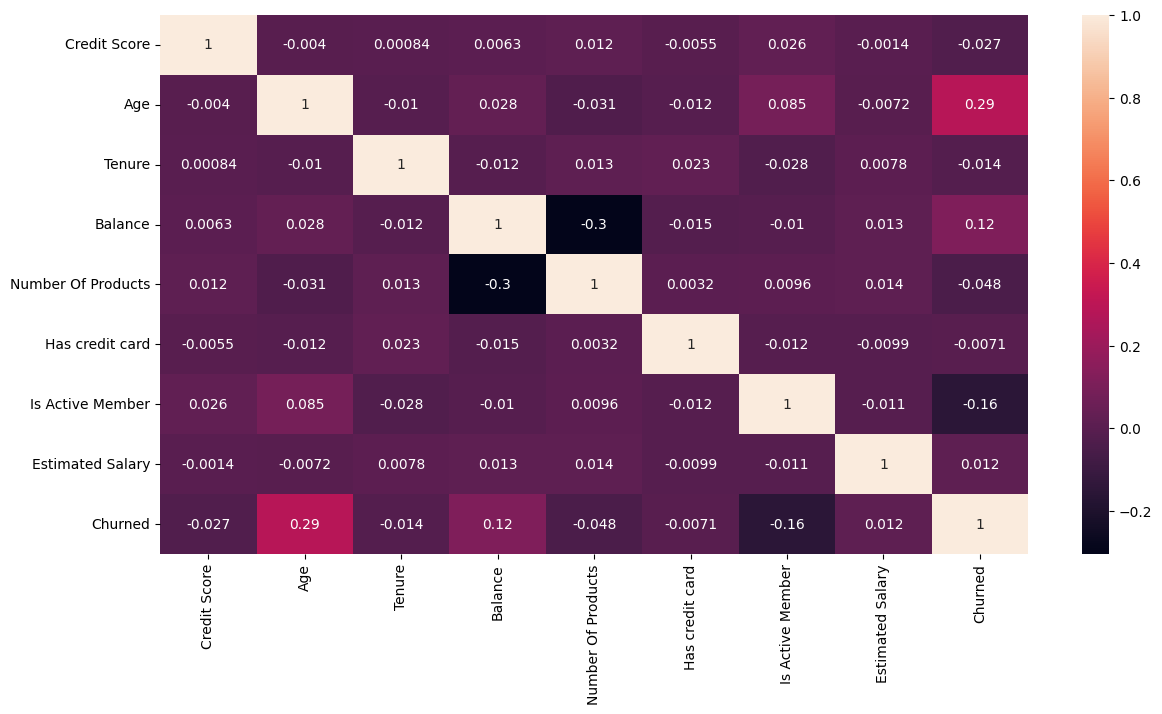

In [14]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

- ##### There is a **normal positive correlation (0.3)** between **Age** and **Exited** 
- ##### There is a **normal negative correlation (-0.3)** between **Balance** and **Number Of Products** 


------------------------------------------
------------------------------------------

## **Feature Extraction**

-----------------------------

In [15]:
def ageGroup(age):
    age = int(age)
    if age <= 40:
        return 'Young Adults'
    elif age > 40 and age < 60:
        return 'Middle-aged Adults'
    else :
        return 'Old Adults'
    
df['Age group'] = df['Age'].apply(lambda x : ageGroup(x))

In [16]:
df['Age group'].value_counts()

Age group
Young Adults          6419
Middle-aged Adults    3055
Old Adults             526
Name: count, dtype: int64

----------------------------------

In [17]:
def balanceGroup(balance):
    balance = float(balance)
    if balance > 0:
        return 'Funded account'
    elif balance == 0:
        return 'Empty account'
    else:
        return 'Overdrawn account'

df['Balance category'] = df['Balance'].apply(lambda x : balanceGroup(x))

In [18]:
df['Balance category'].value_counts()

Balance category
Funded account    6383
Empty account     3617
Name: count, dtype: int64

-----------------------------

In [19]:
def activeGroup(actAcc):
    actAcc = int(actAcc)
    if actAcc == 1:
        return 'Active account'
    else:
        return 'Dormant account'

df['Is Active Member'] = df['Is Active Member'].apply(lambda x : activeGroup(x))

In [20]:
df['Is Active Member'].value_counts()

Is Active Member
Active account     5151
Dormant account    4849
Name: count, dtype: int64

------------------------------------

In [21]:
def cardGroup(card):
    card = int(card)
    if card == 1:
        return 'Has a card'
    else:
        return 'No'

df['Has credit card'] = df['Has credit card'].apply(lambda x : cardGroup(x))

In [22]:
df['Has credit card'].value_counts()

Has credit card
Has a card    7055
No            2945
Name: count, dtype: int64

--------------------------------

In [23]:
def categorize_credit(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    elif score < 800:
        return 'Very Good'
    else:
        return 'Excellent'

df['Credit Score Category'] = df['Credit Score'].apply(categorize_credit)

In [24]:
df['Credit Score Category'].value_counts()

Credit Score Category
Fair         3331
Good         2428
Poor         2362
Very Good    1224
Excellent     655
Name: count, dtype: int64

-----------------------

In [25]:
def categorize_Estimated_Salary(Salary):
    if Salary < 50000:
        return 'Low Salary'
    elif Salary < 100000:
        return 'Medium Salary'
    elif Salary < 150000:
        return 'High Salary'
    else:
        return 'Very High Salary'

df['Estimated Salary Category'] = df['Estimated Salary'].apply(categorize_Estimated_Salary)

In [26]:
df['Estimated Salary Category'].value_counts()

Estimated Salary Category
High Salary         2555
Medium Salary       2537
Very High Salary    2455
Low Salary          2453
Name: count, dtype: int64

------------------------------------

In [27]:
df['BalanceSalaryRatio'] = df['Balance'] / df['Estimated Salary']

In [28]:
df[['Balance', 'Estimated Salary', 'BalanceSalaryRatio']].head()

,Balance,Estimated Salary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744677
2,159660.80,113931.57,1.401375
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587055


In [29]:
#df.to_excel('bank customer churn new dataset.xlsx',index=False)

----------------------------
----------------------------


## **Analysis**

--------------------------------
- ### ***Churn Analysis***
---------------------------------

In [30]:
p_churn = len(df[df['Churned']==1])/len(df)
print(f'{p_churn*100:.2f} %')

20.37 %


In [31]:
# Expected value
n = 1000
expected = n * p_churn
print(f'Expected churn people : {round(expected)}')

Expected churn people : 204


In [32]:
variance = p_churn * (1 - p_churn) / n
std = np.sqrt(variance)
print("Variance:", variance)
print(f'Standard Error : {std*100:.2f} %')

Variance: 0.00016220630999999998
Standard Error : 1.27 %


##### We took different samples from customers, and the percentage change will typically be 1.27%

In [33]:
# Confidence Interval for 95 %
# Confidence Interval = p ​± 1.96 × Standard Error
CI1 = p_churn + 1.96 * std
CI2 = p_churn - 1.96 * std

print(f'[{CI2:0.2f} , {CI1:0.2f}]')

[0.18 , 0.23]


#### We are 95% confident that the true customer exit rate lies between 17.9% and 22.9%

In [34]:
# (CI1-CI2)*100 = 5 ---> narrow interval

In [35]:
# Interval of exited customers
lower_customers = 0.18*n
upper_customers = 0.23*n
print(f'[{upper_customers:0.0f} , {lower_customers:0.0f}] customers')

[230 , 180] customers


#### Based on the sample, the expected number of churned customers is 204 out of 1000
#### A 95% confidence interval estimates that the true number of churned customers likely falls between 179 and 229 customers

------------------------------
- ### ***Analysis of Gender and Age vs Churn***
------------------------------- 

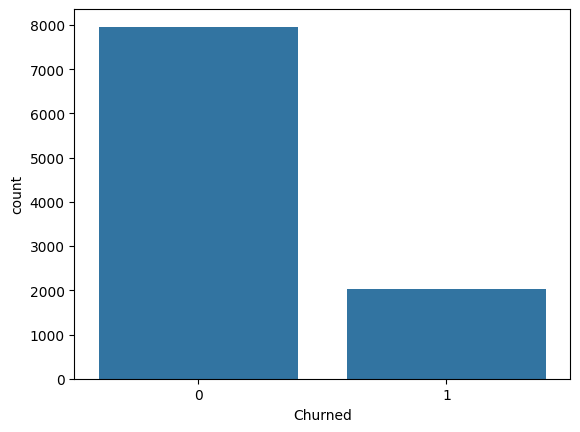

In [36]:
countplot(df,'Churned')

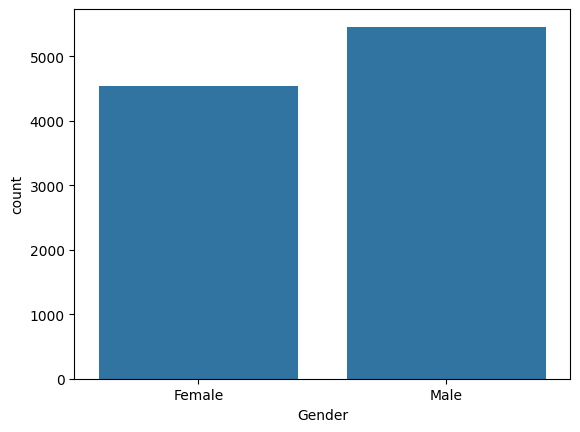

In [37]:
countplot(df,'Gender')

- ##### **Age distibution by gender**

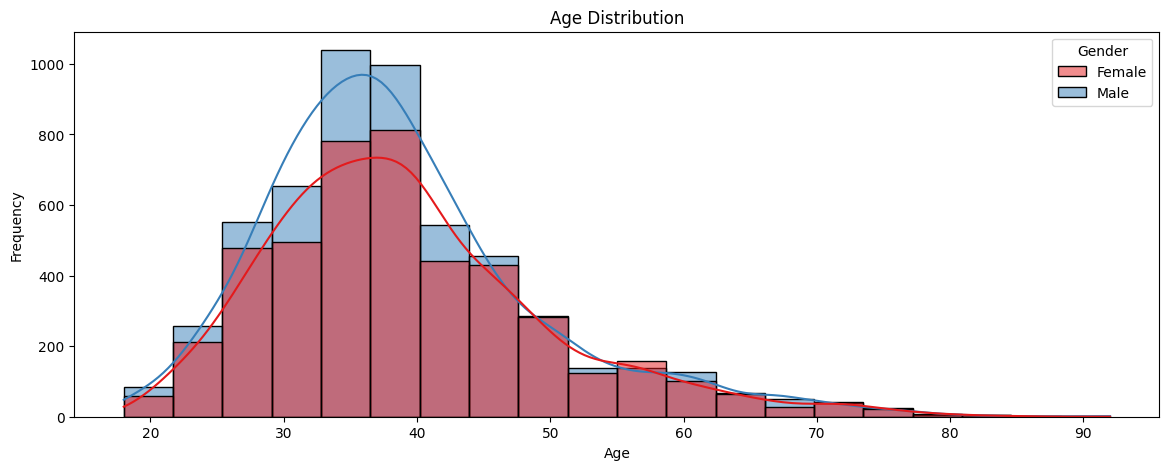

In [38]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='Age', hue='Gender', kde=True, bins=20, palette='Set1')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

##### **The male age distribution is represented by the blue bars and curve.**

##### **The peak frequency for males is slightly older than for females, peaking around the late 30s to early 40s.**

##### **The count of males is consistently higher than females across the majority of the age range shown.**


----------------------
- #### **Comparison of Churn between Males and Females by correlation and probability**
-------------------------

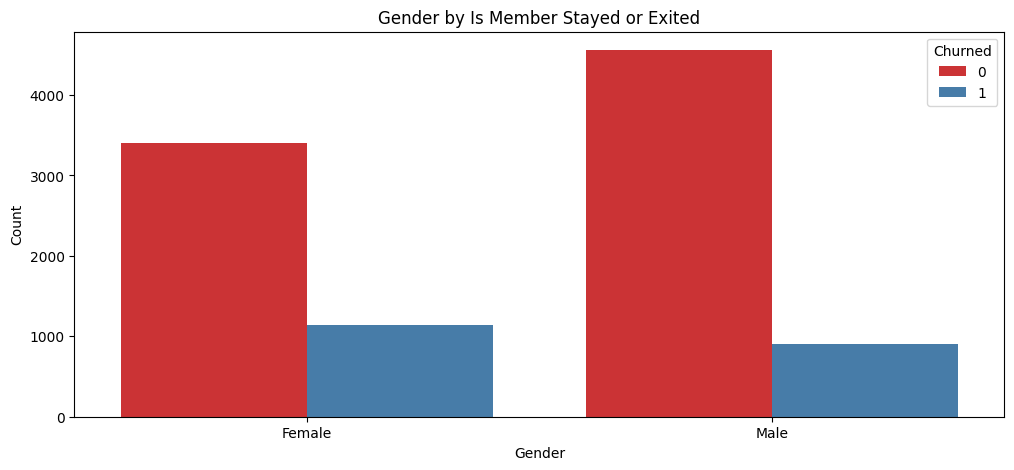

In [39]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x = 'Gender', hue='Churned',palette='Set1')
plt.title('Gender by Is Member Stayed or Exited')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [40]:
crosstab = pd.crosstab(df['Gender'], df['Churned'])
crosstab

Churned,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [41]:
rs = stats.chi2_contingency(crosstab)
print(rs[3])
print('p_val : ',rs[1])
if rs[1] < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

[[3617.5909  925.4091]
 [4345.4091 1111.5909]]
p_val :  2.2482100097131755e-26
There is a significant difference ---> H0 is rejected


In [42]:
p_churn_given_male = len(df[(df['Churned']==1) & (df['Gender']=='Male')]) / len(df[df['Gender']=='Male'])
print(f'P(churned | male) : {p_churn_given_male*100:.2f} %')

P(churned | male) : 16.46 %


In [45]:
p_female_given_churned = len(df[(df['Churned']==1) & (df['Gender']=='Female')]) / len(df[df['Gender']=='Female']) 
print(f'P(churned ∣ female) : {p_female_given_churned*100:.2f} %')

P(churned ∣ female) : 25.07 %


##### Gender is a significant factor in predicting of churn


In [44]:
c

NameError: name 'c' is not defined

--------------------------------
- #### **Comparison of Churn between Age groups by correlation and probability**
-------------------------------

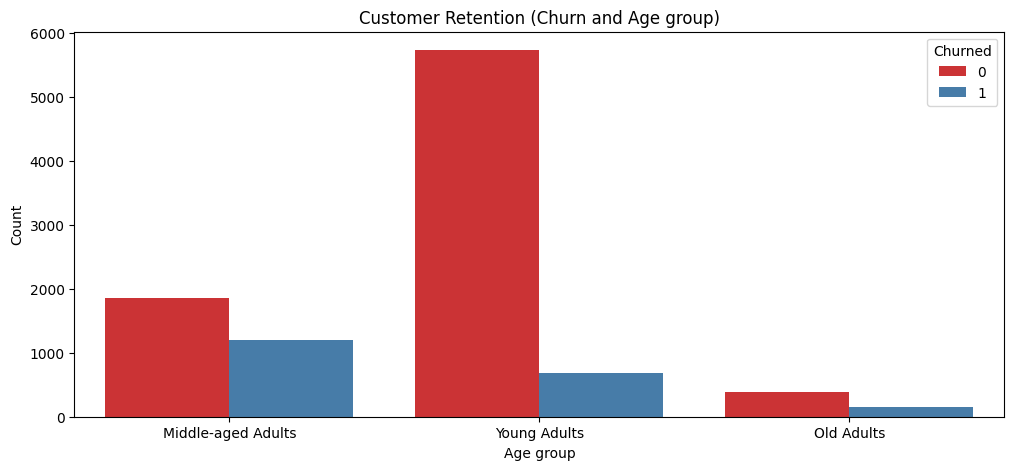

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Age group', hue='Churned',palette='Set1')
plt.title('Customer Retention (Churn and Age group)')
plt.xlabel('Age group')
plt.ylabel('Count')
plt.show()

In [ ]:
crosstab = pd.crosstab(df['Age group'],df['Churned'])
crosstab

Churned,0,1
Age group,,
Middle-aged Adults,1851,1204
Old Adults,379,147
Young Adults,5733,686


In [ ]:
rs = stats.chi2_contingency(crosstab)
print(rs[3])
print('p_val : ',rs[1])
if rs[1] < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

[[2432.6965  622.3035]
 [ 418.8538  107.1462]
 [5111.4497 1307.5503]]
p_val :  1.2965157989610134e-233
There is a significant difference ---> H0 is rejected


- ##### Old adults Churn probability

In [ ]:
p_old_adults_given_churned = len(df[(df['Churned']==1) & (df['Age group']=='Old Adults')])/len(df[df['Churned']==1])

p_intersection_old_adults_churn = p_churn * p_old_adults_given_churned
print(f'P(churned ∩ old adults) : {p_intersection_old_adults_churn*100:.2f} %')

P(churned ∩ old adults) : 1.47 %


- ##### Middle age adults Churn probability

In [ ]:
p_middle_age_adults_given_churned = len(df[(df['Churned']==1) & (df['Age group']=='Middle-aged Adults')])/len(df[df['Churned']==1])

p_intersection_Middle_aged_Adults_churn = p_churn * p_middle_age_adults_given_churned
print(f'P(churned ∩ Middle-aged Adults) : {p_intersection_Middle_aged_Adults_churn*100:.2f} %')

P(churned ∩ Middle-aged Adults) : 12.04 %


- ##### Young adults Churn probability

In [ ]:
p_intersection_young_adults_churn = p_churn - (p_intersection_old_adults_churn + p_intersection_Middle_aged_Adults_churn) 
print(f'P(churned ∩ Middle_aged_Adults) : {p_intersection_young_adults_churn*100:.2f} %')

P(churned ∩ Middle_aged_Adults) : 6.86 %


##### Age is a significant factor in predicting of churn
##### The Middle-aged Adults category is leaving at a rate that doubles statistical projections
##### Retention campaigns and targeted offers should be specifically aimed at this demographic, while "Young Adults" can currently be considered a stable customer base.

-----------------------------
- #### **Comparison of Churn probability between Countries**
------------------------------

- ##### France Churn probability

In [ ]:
p_france_given_churned = len(df[(df['Geography']=='France') & (df['Churned']==1)])/len(df[df['Churned']==1])
p_intersection_france_churn = p_churn * p_france_given_churned
print(f'P(churned ∩ france) : {p_intersection_france_churn *100:.2f} %')

P(churned ∩ france) : 8.10 %


- ##### Spain Churn probability

In [ ]:
p_spain_given_churned = len(df[(df['Geography']=='Spain') & (df['Churned']==1)])/len(df[df['Churned']==1])
p_intersection_spain_churn = p_churn * p_spain_given_churned
print(f'P(churned ∩ spain) : {p_intersection_spain_churn *100:.2f} %')

P(churned ∩ spain) : 4.13 %


- ##### Germany Churn probability

In [ ]:
p_intersection_germany_churn = p_churn - (p_intersection_france_churn + p_intersection_spain_churn)
print(f'P(churned ∩ germany) : {p_intersection_germany_churn *100:.2f} %')

P(churned ∩ germany) : 8.14 %


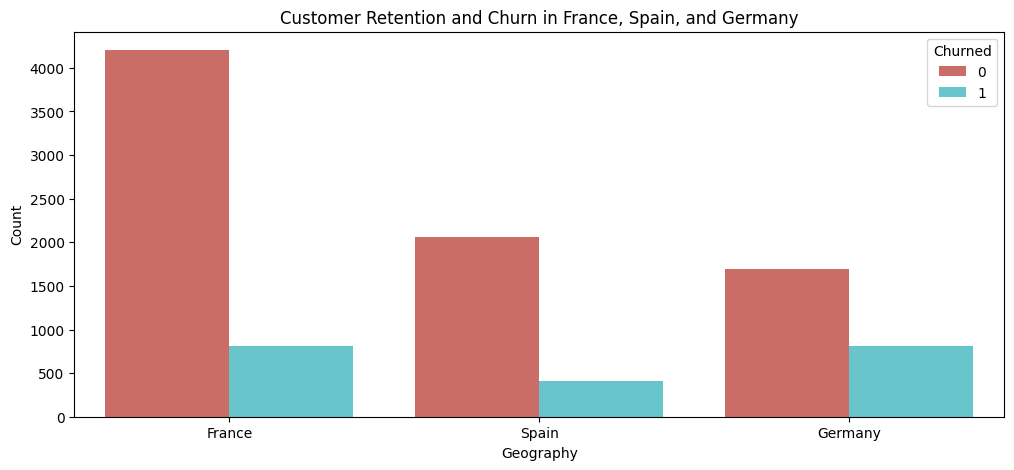

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Geography', hue='Churned',palette='hls')
plt.title('Customer Retention and Churn in France, Spain, and Germany')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

- ##### **France has the largest total customer base.**

- ##### **The number of customers who exited is roughly the same for France and Germany, despite France having a much larger total customer base.**

- ##### **The number of customers who exited is the lowest in Spain.**

- ##### **When looking at the proportion of customers who exited, Germany has the highest churn rate, followed by France. Spain has the lowest churn rate.**
---------------------------------

- #### **Comparison of Estimated Salary Category Between Males and Females**

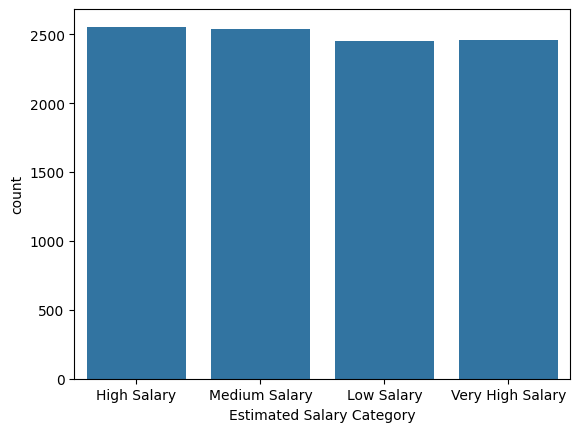

In [ ]:
countplot(df,'Estimated Salary Category')

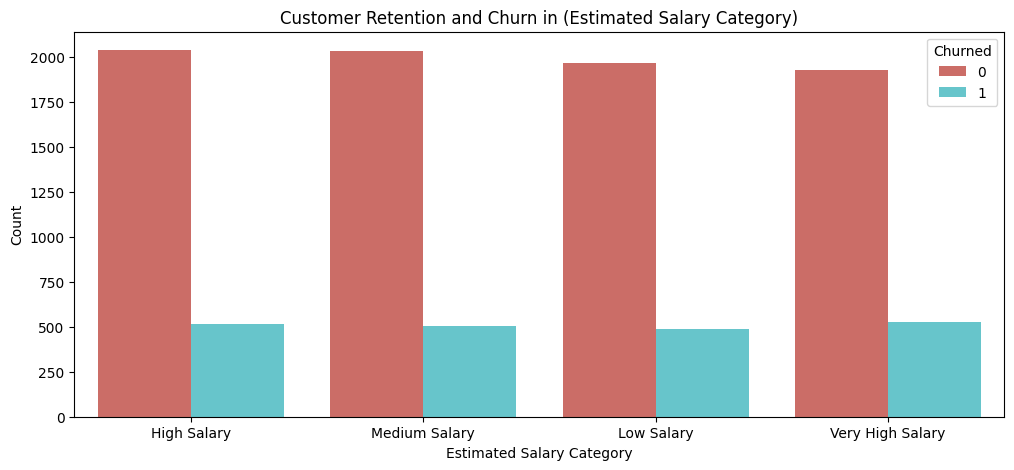

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Estimated Salary Category', hue='Churned',palette='hls')
plt.title('Customer Retention and Churn in (Estimated Salary Category)')
plt.xlabel('Estimated Salary Category')
plt.ylabel('Count')
plt.show()

In [ ]:
crosstab = pd.crosstab(df['Estimated Salary Category'],df['Churned'])
crosstab

Churned,0,1
Estimated Salary Category,,
High Salary,2038,517
Low Salary,1964,489
Medium Salary,2033,504
Very High Salary,1928,527


In [ ]:
chi2, pval, dof, expected = stats.chi2_contingency(crosstab)
print(pval)

if pval < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

0.46955109096180025
There is not a significant difference ---> H0 is not rejacted


##### There is no statistically significant relationship between Estimated salary and Churned
##### Salary level does not appear to clearly influence churn within this data
##### High- and low-paying customers leave in relatively similar proportions

----------------------------
- #### **Comparison of Credit Score Category Between customers who left and those who stayed**
----------------------------

- ##### **Effect of having credit card on the possibility of leaving**

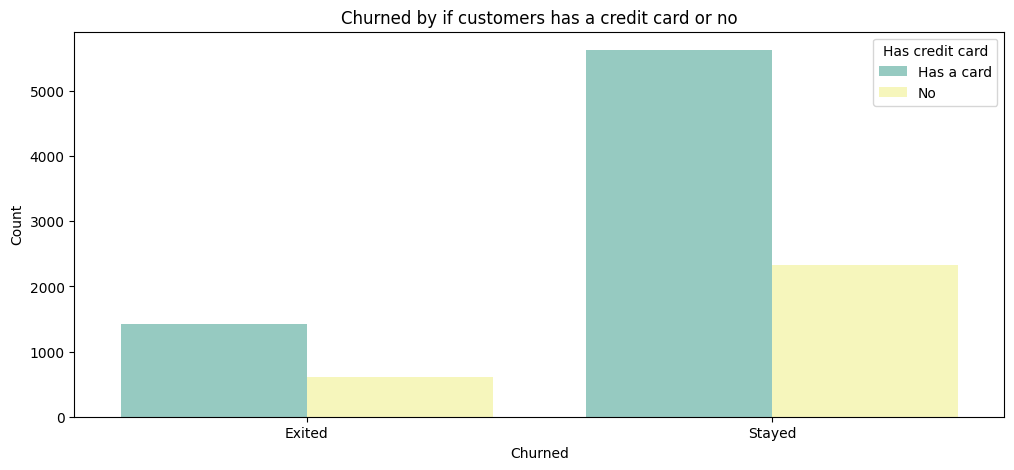

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Churned', hue='Has credit card', palette='Set3')
plt.title('Churned by if customers has a credit card or no')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

#### **The chart shows that the total number of leavers who are cardholders is larger simply because there are more of them to begin with. But when we look at the risk for each individual customer, we find that:**

- ##### **A customer who has a credit card has a higher probability (27%) of leaving.**

- ##### **A customer who does not have a credit card has a lower probability (20%) of leaving.**

#### **Therefore, having a credit card is associated with an increased risk of customer churn, and not having one is a minor factor that helps retain the customer. You are seeing the total number, but the important part is the proportion within each group.**

------------------------------------

- ##### **Effect of active member or no on the possibility of leaving**

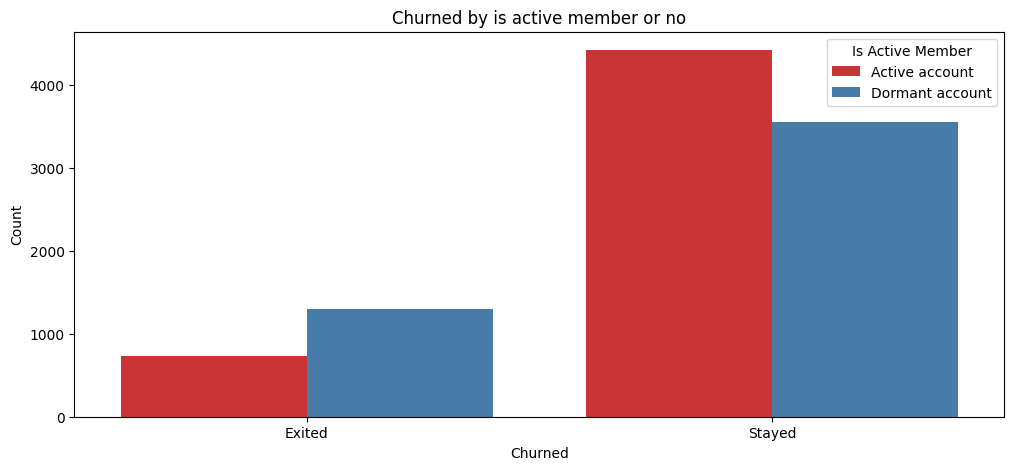

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data = df, x ='Churned', hue='Is Active Member', palette='Set1')
plt.title('Churned by is active member or no')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

- ##### **Customers with a dormant account have an extremely high estimated churn rate of ~60%. This means a customer who is not active has a very high possibility of leaving.**

- ##### **Conversely, customers with an active account have a very low estimated churn rate of ~12.5%.**

##### **Therefore, being an inactive (dormant) member is the strongest predictor of customer churn visible in this chart. Activity status is a critically important factor; an inactive customer is several times more likely to leave than an active one.**
-----------------------

### ***Study Customer behavior***
-------------------

- ##### **Do customers with Num Of Products = 1 tend to leave more or less often ?**

In [ ]:
nmbOfProdEq1 = df[df['Number Of Products']==1]
nmbOfProdEq1

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
0,619,France,Female,42,2,0.00,1,Has a card,Active account,101348.88,Exited,Middle-aged Adults,Empty account,Fair,High Salary,0.000000
1,608,Spain,Female,41,1,83807.86,1,No,Active account,112542.58,Stayed,Middle-aged Adults,Funded account,Fair,High Salary,0.744677
4,850,Spain,Female,43,2,125510.82,1,Has a card,Active account,79084.10,Stayed,Middle-aged Adults,Funded account,Excellent,Medium Salary,1.587055
9,684,France,Male,27,2,134603.88,1,Has a card,Active account,71725.73,Stayed,Young Adults,Funded account,Good,Medium Salary,1.876647
16,653,Germany,Male,58,1,132602.88,1,Has a card,Dormant account,5097.67,Exited,Middle-aged Adults,Funded account,Fair,Low Salary,26.012449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,726,Spain,Male,36,2,0.00,1,Has a card,Dormant account,195192.40,Stayed,Young Adults,Empty account,Good,Very High Salary,0.000000
9993,644,France,Male,28,7,155060.41,1,Has a card,Dormant account,29179.52,Stayed,Young Adults,Funded account,Fair,Low Salary,5.314015
9996,516,France,Male,35,10,57369.61,1,Has a card,Active account,101699.77,Stayed,Young Adults,Funded account,Poor,High Salary,0.564108
9997,709,France,Female,36,7,0.00,1,No,Active account,42085.58,Exited,Young Adults,Empty account,Good,Low Salary,0.000000


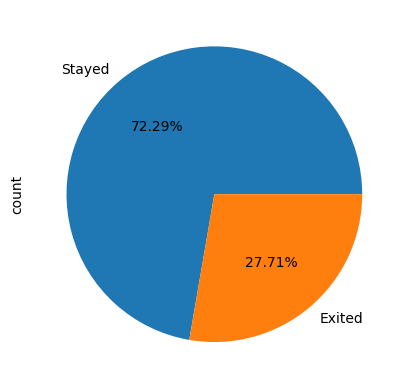

In [ ]:
nmbOfProdEq1['Churned'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

---------------------------

- ##### **Do customers with Num Of Products = 2 or more tend to leave more or less often ?**

In [ ]:
nmbOfProdGte2 = df[df['Number Of Products']>=2]
nmbOfProdGte2

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
2,502,France,Female,42,8,159660.80,3,Has a card,Dormant account,113931.57,Exited,Middle-aged Adults,Funded account,Poor,High Salary,1.401375
3,699,France,Female,39,1,0.00,2,No,Dormant account,93826.63,Stayed,Young Adults,Empty account,Good,Medium Salary,0.000000
5,645,Spain,Male,44,8,113755.78,2,Has a card,Dormant account,149756.71,Exited,Middle-aged Adults,Funded account,Fair,High Salary,0.759604
6,822,France,Male,50,7,0.00,2,Has a card,Active account,10062.80,Stayed,Middle-aged Adults,Empty account,Excellent,Low Salary,0.000000
7,376,Germany,Female,29,4,115046.74,4,Has a card,Dormant account,119346.88,Exited,Young Adults,Funded account,Poor,High Salary,0.963969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,775,France,Male,30,4,0.00,2,Has a card,Dormant account,49337.84,Stayed,Young Adults,Empty account,Very Good,Low Salary,0.000000
9989,841,Spain,Male,28,4,0.00,2,Has a card,Active account,179436.60,Stayed,Young Adults,Empty account,Excellent,Very High Salary,0.000000
9994,800,France,Female,29,2,0.00,2,No,Dormant account,167773.55,Stayed,Young Adults,Empty account,Excellent,Very High Salary,0.000000
9995,771,France,Male,39,5,0.00,2,Has a card,Dormant account,96270.64,Stayed,Young Adults,Empty account,Very Good,Medium Salary,0.000000


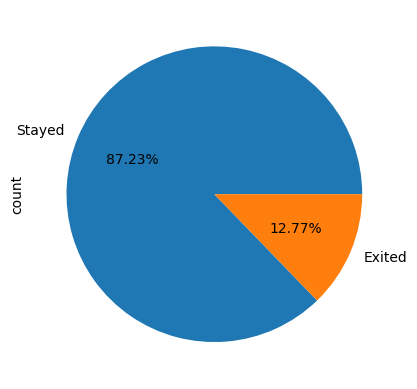

In [ ]:
nmbOfProdGte2['Churned'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

----------------------------------

- ##### **Do customers with tenure < 3 years tend to leave more or less often ?**

In [ ]:
tenureLt3years = df[df['Tenure']<3]
tenureLt3years

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
0,619,France,Female,42,2,0.00,1,Has a card,Active account,101348.88,Exited,Middle-aged Adults,Empty account,Fair,High Salary,0.000000
1,608,Spain,Female,41,1,83807.86,1,No,Active account,112542.58,Stayed,Middle-aged Adults,Funded account,Fair,High Salary,0.744677
3,699,France,Female,39,1,0.00,2,No,Dormant account,93826.63,Stayed,Young Adults,Empty account,Good,Medium Salary,0.000000
4,850,Spain,Female,43,2,125510.82,1,Has a card,Active account,79084.10,Stayed,Middle-aged Adults,Funded account,Excellent,Medium Salary,1.587055
9,684,France,Male,27,2,134603.88,1,Has a card,Active account,71725.73,Stayed,Young Adults,Funded account,Good,Medium Salary,1.876647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9975,610,Germany,Male,50,1,113957.01,2,Has a card,Dormant account,196526.55,Exited,Middle-aged Adults,Funded account,Fair,Very High Salary,0.579856
9979,677,France,Female,58,1,90022.85,1,No,Active account,2988.28,Stayed,Middle-aged Adults,Funded account,Good,Low Salary,30.125306
9986,673,Germany,Male,47,1,183579.54,2,No,Active account,34047.54,Stayed,Middle-aged Adults,Funded account,Good,Low Salary,5.391859
9992,726,Spain,Male,36,2,0.00,1,Has a card,Dormant account,195192.40,Stayed,Young Adults,Empty account,Good,Very High Salary,0.000000


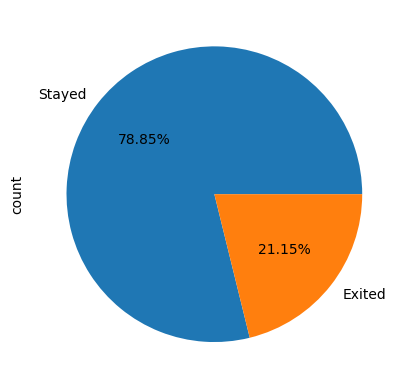

In [ ]:
tenureLt3years['Churned'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

---------------------------
- ##### **Do customers with tenure = 3 years or more tend to leave more or less often ?**

In [ ]:
tenureGte3years = df[df['Tenure']>=3]
tenureGte3years

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
2,502,France,Female,42,8,159660.80,3,Has a card,Dormant account,113931.57,Exited,Middle-aged Adults,Funded account,Poor,High Salary,1.401375
5,645,Spain,Male,44,8,113755.78,2,Has a card,Dormant account,149756.71,Exited,Middle-aged Adults,Funded account,Fair,High Salary,0.759604
6,822,France,Male,50,7,0.00,2,Has a card,Active account,10062.80,Stayed,Middle-aged Adults,Empty account,Excellent,Low Salary,0.000000
7,376,Germany,Female,29,4,115046.74,4,Has a card,Dormant account,119346.88,Exited,Young Adults,Funded account,Poor,High Salary,0.963969
8,501,France,Male,44,4,142051.07,2,No,Active account,74940.50,Stayed,Middle-aged Adults,Funded account,Poor,Medium Salary,1.895518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,Has a card,Dormant account,96270.64,Stayed,Young Adults,Empty account,Very Good,Medium Salary,0.000000
9996,516,France,Male,35,10,57369.61,1,Has a card,Active account,101699.77,Stayed,Young Adults,Funded account,Poor,High Salary,0.564108
9997,709,France,Female,36,7,0.00,1,No,Active account,42085.58,Exited,Young Adults,Empty account,Good,Low Salary,0.000000
9998,772,Germany,Male,42,3,75075.31,2,Has a card,Dormant account,92888.52,Exited,Middle-aged Adults,Funded account,Very Good,Medium Salary,0.808230


-----------------------------------

### ***Segmentation and analysis***
------------------------

- ##### **Churn Rate by Geography and Credit Score Group**

In [ ]:
df['Churned'].unique()

array(['Exited', 'Stayed'], dtype=object)

In [ ]:
df['Churned_numeric'] = df['Churned'].map({'Exited': 1, 'Stayed': 0})
df['Churned_numeric']

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Churned_numeric, Length: 10000, dtype: int64

In [ ]:
# Verify the conversion
print("Unique values in Churned_numeric column:", df['Churned_numeric'].unique())
print(f"Churn rate: {df['Churned_numeric'].mean()*100:.2f}%")

Unique values in Churned_numeric column: [1 0]
Churn rate: 20.37%


In [ ]:
# Check the unique values in the 'Geography' column
print("Countries in the dataset:", df['Geography'].unique())

Countries in the dataset: ['France' 'Spain' 'Germany']


In [ ]:
# Get basic statistics for CreditScore by Country
print("\nCredit Score statistics by country:")
print(df.groupby('Geography')['Credit Score Category'].describe())


Credit Score statistics by country:
          count unique   top  freq
Geography                         
France     5014      5  Fair  1621
Germany    2509      5  Fair   861
Spain      2477      5  Fair   849


In [ ]:
# Define a threshold for "low" credit score (bottom 25th percentile)
low_score_threshold = df['Credit Score'].quantile(0.25)
print(f"\nLow Credit Score Threshold (25th percentile): {low_score_threshold}")


Low Credit Score Threshold (25th percentile): 584.0


In [ ]:
# Create a new column to flag customers with low credit scores
df['LowCreditScore'] = df['Credit Score'] < low_score_threshold
df['LowCreditScore']

0       False
1       False
2        True
3       False
4       False
        ...  
9995    False
9996     True
9997    False
9998    False
9999    False
Name: LowCreditScore, Length: 10000, dtype: bool

In [ ]:
# Create a summary table using the numeric column
churn_analysis = df.groupby(['Geography', 'LowCreditScore'])['Churned_numeric'].agg(['mean', 'count', 'sum'])
churn_analysis['mean'] = churn_analysis['mean'] * 100 # Convert to percentage
churn_analysis = churn_analysis.rename(columns={
    'mean': 'ChurnRate (%)', 
    'sum': 'Num_Churned', 
    'count': 'Total_Customers'
})

print("\nChurn Analysis by Geography and Credit Score Group:")
print(churn_analysis)


Churn Analysis by Geography and Credit Score Group:
                          ChurnRate (%)  Total_Customers  Num_Churned
Geography LowCreditScore                                             
France    False               15.679443             3731          585
          True                17.537023             1283          225
Germany   False               31.378764             1893          594
          True                35.714286              616          220
Spain     False               16.445623             1885          310
          True                17.398649              592          103


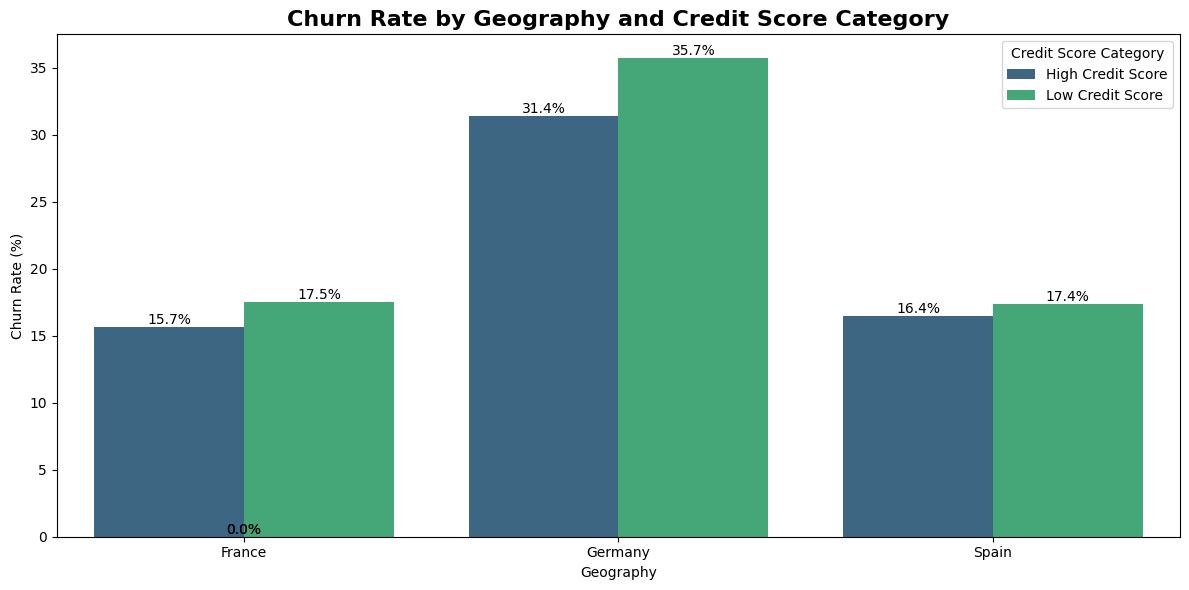

In [ ]:
# Prepare data for plotting
pivot_df = df.groupby(['Geography', 'LowCreditScore'])['Churned_numeric'].mean().reset_index()
pivot_df['Churned_numeric'] = pivot_df['Churned_numeric'] * 100 # Convert to percentage

# Create the plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Geography', y='Churned_numeric', hue='LowCreditScore', 
                 data=pivot_df, palette='viridis')

plt.title('Churn Rate by Geography and Credit Score Category', fontsize=16, fontweight='bold')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')

# Customize legend labels
legend_labels = ['High Credit Score', 'Low Credit Score']
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, title='Credit Score Category')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##### **Customers with low credit scores are significantly more likely to churn, and this pattern holds true across all three countries. The risk is most severe in Germany and Spain, where approximately 35% of low credit score customers churn. France shows the same trend but with a slightly lower overall churn rate.**

In [ ]:
# Test for a specific country, e.g., Germany
country_to_test = 'Germany'

germany_data = df[df['Geography'] == country_to_test]
germany_low = germany_data[germany_data['LowCreditScore']]['Churned_numeric']
germany_high = germany_data[~germany_data['LowCreditScore']]['Churned_numeric']

print(f"\nStatistical test for {country_to_test}:")
print(f"Low credit score group: {len(germany_low)} customers, churn rate: {germany_low.mean()*100:.1f}%")
print(f"High credit score group: {len(germany_high)} customers, churn rate: {germany_high.mean()*100:.1f}%")

# Perform T-test
t_stat, p_value = stats.ttest_ind(germany_low, germany_high, alternative='greater')

print(f"T-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("The difference is statistically significant.")
else:
    print("The difference is not statistically significant.")


Statistical test for Germany:
Low credit score group: 616 customers, churn rate: 35.7%
High credit score group: 1893 customers, churn rate: 31.4%
T-test: t-statistic = 1.9972, p-value = 0.0230
The difference is statistically significant.


-------------------------------
-------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
#### ****

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "bank customer churn analysis.ipynb"

[NbConvertApp] Converting notebook bank customer churn analysis.ipynb to html
C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 31 image(s).
[NbConvertApp] Writing 1553483 bytes to bank customer churn analysis.html
